# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 2. Chargement des données

In [2]:
# Ratings
ratings = pd.read_csv(
    "../data/raw/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

# Movies
movies = pd.read_csv(
    "../data/raw/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

movies = movies[[0, 1]]
movies.columns = ["movie_id", "title"]

# Users
users = pd.read_csv(
    "../data/raw/u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"]
)

# 3. Aperçu des données

In [3]:
ratings.head()
movies.head()
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


# 4. Dimensions du dataset

In [4]:
print("Ratings:", ratings.shape)
print("Movies:", movies.shape)
print("Users:", users.shape)

print("\nUnique users:", ratings["user_id"].nunique())
print("Unique movies:", ratings["movie_id"].nunique())
print("Total ratings:", len(ratings))

Ratings: (100000, 4)
Movies: (1682, 2)
Users: (943, 5)

Unique users: 943
Unique movies: 1682
Total ratings: 100000


# 5. Distribution des ratings

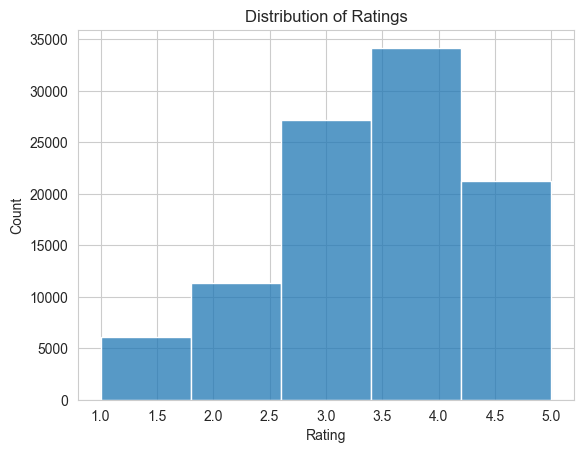

In [5]:
plt.figure()
sns.histplot(ratings["rating"], bins=5)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# 6. Sparsity

In [6]:
n_users = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()

sparsity = 1 - (len(ratings) / (n_users * n_movies))

print(f"Sparsity: {sparsity:.2%}")

Sparsity: 93.70%


# 7. Activité des utilisateurs

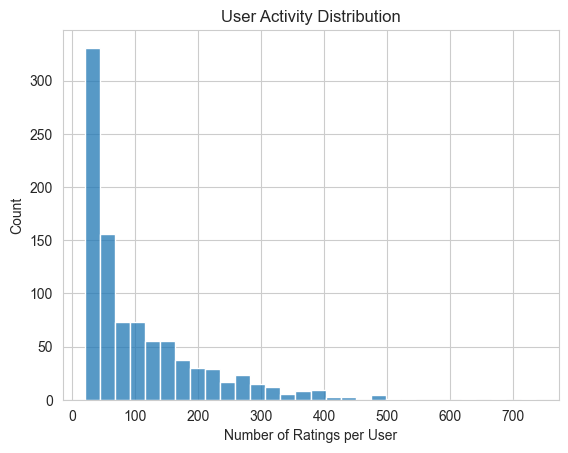

In [7]:
user_activity = ratings.groupby("user_id").size()

plt.figure()
sns.histplot(user_activity, bins=30)
plt.title("User Activity Distribution")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Count")
plt.show()

# Analyse des outliers

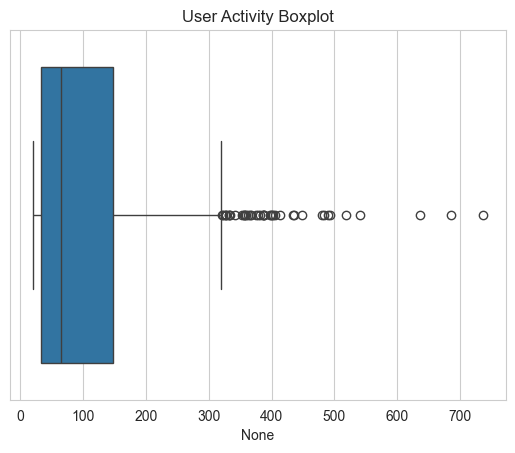

In [8]:
plt.figure()
sns.boxplot(x=user_activity)
plt.title("User Activity Boxplot")
plt.show()

# 8. Popularité des films

In [9]:
movie_popularity = ratings.groupby("movie_id").size().sort_values(ascending=False)

print("Top 10 most popular movies:")
print(movie_popularity.head(10))

Top 10 most popular movies:
movie_id
50     583
258    509
100    508
181    507
294    485
286    481
288    478
1      452
300    431
121    429
dtype: int64


# 9. Fusion ratings + movies

In [10]:
df = ratings.merge(movies, on="movie_id")
df.head()

,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


# 10. Top films

In [11]:
top_movies = df.groupby("title").size().sort_values(ascending=False).head(10)

print(top_movies)

title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
dtype: int64


# 11. Long-tail distribution

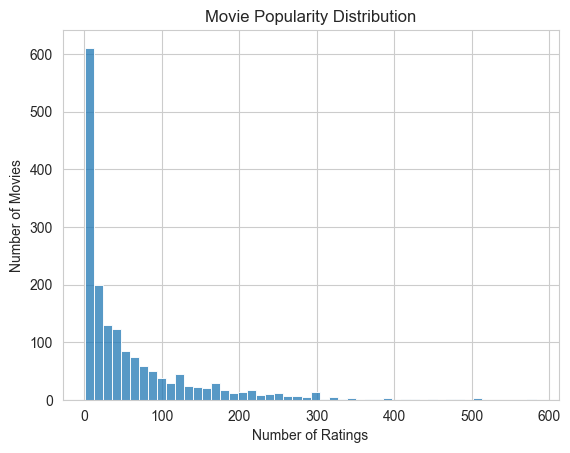

In [12]:
plt.figure()
sns.histplot(movie_popularity, bins=50)
plt.title("Movie Popularity Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

# 12. Nettoyage des données

In [13]:
print("Before cleaning:", ratings.shape)

ratings = ratings.drop_duplicates()
ratings = ratings.dropna()

print("After cleaning:", ratings.shape)

Before cleaning: (100000, 4)
After cleaning: (100000, 4)


# 13. Sauvegarde des données propres

In [14]:
ratings.to_csv("../data/processed/ratings_clean.csv", index=False)
movies.to_csv("../data/processed/movies_clean.csv", index=False)
users.to_csv("../data/processed/users_clean.csv", index=False)

# 14. INTERPRÉTATION

## Key Insights

- The dataset contains 943 users and 1682 movies with 100K interactions.
- The data is highly sparse (>90%), which is typical for recommendation systems.
- Ratings are skewed toward higher values (positive bias).
- User activity is uneven: a small number of users are highly active.
- Movie popularity follows a long-tail distribution.